In [ ]:
!pip install shap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 575 kB 4.6 MB/s 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import math
from math import sqrt
import shap

In [ ]:
df = pd.read_csv('/content/forestfires.csv')

In [ ]:
# data from University of California, Irving


# X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
# Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
# month - month of the year: "jan" to "dec"
# day - day of the week: "mon" to "sun"
# FFMC - FFMC index from the FWI system: 18.7 to 96.20
# DMC - DMC index from the FWI system: 1.1 to 291.3
# DC - DC index from the FWI system: 7.9 to 860.6
# ISI - ISI index from the FWI system: 0.0 to 56.10
# temp - temperature in Celsius degrees: 2.2 to 33.30
# RH - relative humidity in %: 15.0 to 100
# wind - wind speed in km/h: 0.40 to 9.40
# rain - outside rain in mm/m2 : 0.0 to 6.4
# area - the burned area of the forest (in ha): 0.00 to 1090.84
# (this output variable is very skewed towards 0.0, thus it may make
# sense to model with the logarithm transform).

In [ ]:
df = df.drop("X",axis=1)
df = df.drop("Y",axis=1)

In [ ]:
m = {'jan':1, 'feb':2,"mar":3,"apr":4,"may":5,"jun":6,"jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12}
df.month = df.month.map(m)
d = {'mon':1, 'tue':2,"wed":3,"thu":4,"fri":5,"sat":6,"sun":7}
df.day = df.day.map(d)
df['rain'] = df['rain'].apply(lambda x: int(x > 0.0))
outlier_columns = ['area','FFMC','ISI']
df[outlier_columns] = np.log1p(df[outlier_columns])

In [ ]:
df

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,3,5,4.468204,26.2,94.3,1.808289,8.2,51,6.7,0,0.000000
1,10,2,4.517431,35.4,669.1,2.041220,18.0,33,0.9,0,0.000000
2,10,6,4.517431,43.7,686.9,2.041220,14.6,33,1.3,0,0.000000
3,3,5,4.529368,33.3,77.5,2.302585,8.3,97,4.0,1,0.000000
4,3,7,4.503137,51.3,102.2,2.360854,11.4,99,1.8,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
512,8,7,4.414010,56.7,665.6,1.064711,27.8,32,2.7,0,2.006871
513,8,7,4.414010,56.7,665.6,1.064711,21.9,71,5.8,0,4.012592
514,8,7,4.414010,56.7,665.6,1.064711,21.2,70,6.7,0,2.498152
515,8,6,4.558079,146.0,614.7,2.509599,25.6,42,4.0,0,0.000000


In [ ]:
X = df[['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH','wind','rain','month','day']].values
y = df['area'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=7)

Model #1

In [ ]:
lin_reg = linear_model.LinearRegression()
lin_reg.fit(X_train,y_train)
y_pred = lin_reg.predict(X_test)

In [ ]:
print("RMSE value:",sqrt(mean_squared_error(y_test,y_pred)))

RMSE value: 1.4332478192151705


Model #2

In [ ]:
# We want to sort through various choices for random forest tuning and find the best one
param_grid = {
    'n_estimators':[5,10,15,20,50,100],
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_leaf': [1,2,3],
    'max_leaf_nodes': [10, 20, 30, 35, 50, 55]}
rf = RandomForestRegressor()
gs = GridSearchCV(rf, param_grid, cv=5)
gs.fit(X_train, y_train)

In [ ]:
# The best parameters that grid search found
print(gs.best_params_)

# The score for the best model
print(gs.best_score_)

In [ ]:
rfg = RandomForestRegressor(n_estimators = 50, max_depth = 15, max_leaf_nodes=10, min_samples_leaf=2, random_state = 0)

In [ ]:
rfg.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, max_leaf_nodes=10, min_samples_leaf=2,
                      n_estimators=50, random_state=0)

In [ ]:
y_pred = rfg.predict(X_test)

In [ ]:
sqrt(mean_squared_error(y_test,y_pred))

1.4871821903962832

In [ ]:
ft_imp = pd.Series(rfg.feature_importances_).sort_values(ascending=False)
ft_imp

4    0.213058
1    0.163659
5    0.149477
2    0.118231
3    0.097046
6    0.088708
0    0.074785
8    0.051215
9    0.043821
7    0.000000
dtype: float64

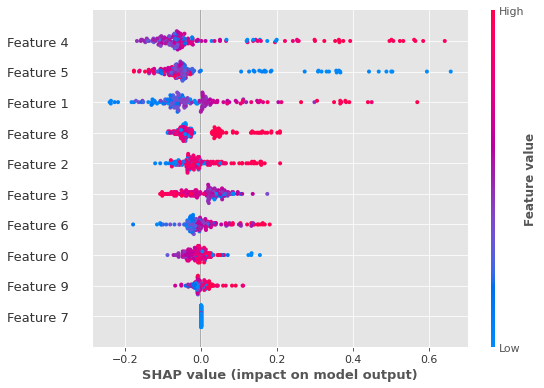

In [ ]:
explainer = shap.TreeExplainer(rfg)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

# f4: temp
# f5: RH
# f1: DMC
# f8: month
# f2: DC
# f3:ISI
# f6: wind
# f0: FFMC
# f9: day
# f7: rain



Model #3

In [ ]:
xg_reg = xgb.XGBRegressor(booster='gbtree', colsample_bylevel=1,
       colsample_bytree=0.21, learning_rate=0.01,
       max_depth=3, n_estimators=150, subsample=1)

In [ ]:
eval_set = [(X_train, y_train), (X_test, y_test)]
xg_reg.fit(X_train, y_train, eval_metric=["rmse"],eval_set=eval_set, verbose=False)
preds = xg_reg.predict(X_test)

[05:11:07] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


In [ ]:
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)

In [ ]:
rmse

1.4642261574213884

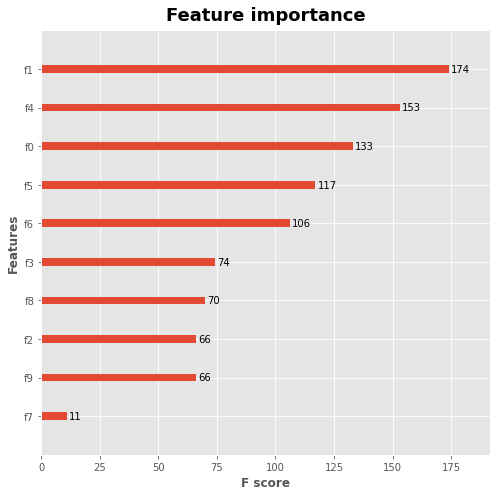

In [ ]:
xgb.plot_importance(xg_reg)
# f0: FFMC
# f1: DMC
# f2: DC
# f3: ISI
# f4: temp
# f5: RH
# f6: wind
# f7: rain
# f8: month
# f9: day

Computer Vision Recognition Fire

In [ ]:
import tensorflow as tf
from tensorflow import keras as ks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as stl
stl.use("ggplot")
import seaborn as sns
import os
from tqdm import tqdm
import cv2

from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Import Data Science Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from PIL import Image

# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras_preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model
from tensorflow.keras.layers.experimental import preprocessing

# System libraries
from pathlib import Path
import os.path

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import itertools

In [ ]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

# Import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir, pred_and_plot

--2023-01-01 03:47:55--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2023-01-01 03:47:56 (49.1 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = (320, 320)

In [ ]:
dataset = "/content/drive/MyDrive/fire_dataset"
walk_through_dir(dataset)

There are 2 directories and 0 images in '/content/drive/MyDrive/fire_dataset'.
There are 0 directories and 755 images in '/content/drive/MyDrive/fire_dataset/fire_images'.
There are 0 directories and 244 images in '/content/drive/MyDrive/fire_dataset/non_fire_images'.


In [ ]:
image_dir = Path(dataset)

# Get filepaths and labels
filepaths = list(image_dir.glob(r'**/*.JPG')) + list(image_dir.glob(r'**/*.jpg')) + list(image_dir.glob(r'**/*.png'))

labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
image_df = pd.concat([filepaths, labels], axis=1)

In [ ]:
len(list(image_dir.glob(r'**/*.png')))

999

In [ ]:
image_df

,Filepath,Label
0,/content/drive/MyDrive/fire_dataset/fire_image...,fire_images
1,/content/drive/MyDrive/fire_dataset/fire_image...,fire_images
2,/content/drive/MyDrive/fire_dataset/fire_image...,fire_images
3,/content/drive/MyDrive/fire_dataset/fire_image...,fire_images
4,/content/drive/MyDrive/fire_dataset/fire_image...,fire_images
...,...,...
994,/content/drive/MyDrive/fire_dataset/non_fire_i...,non_fire_images
995,/content/drive/MyDrive/fire_dataset/non_fire_i...,non_fire_images
996,/content/drive/MyDrive/fire_dataset/non_fire_i...,non_fire_images
997,/content/drive/MyDrive/fire_dataset/non_fire_i...,non_fire_images


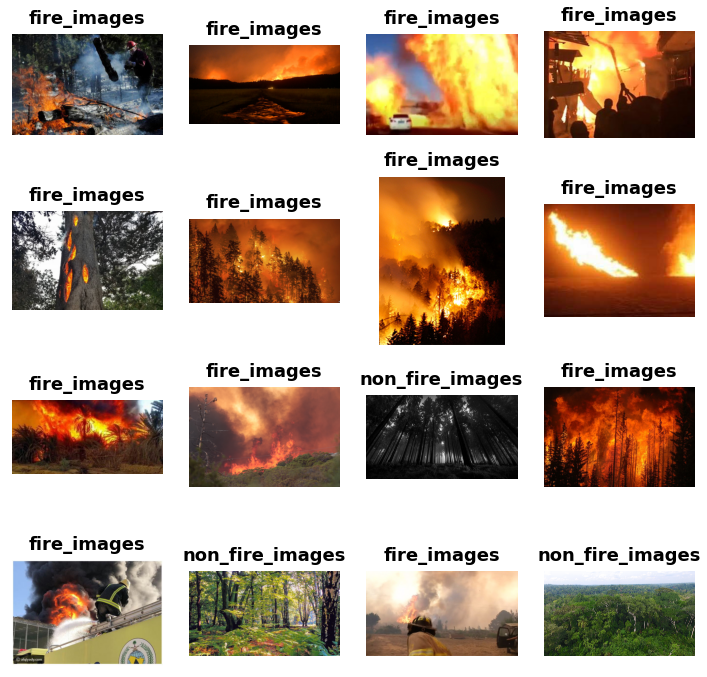

In [ ]:
import matplotlib.image as mpimg
# Display 16 picture of the dataset with their labels
random_index = np.random.randint(0, len(image_df), 16)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    image = Image.open(image_df.Filepath[random_index[i]])
    ax.imshow(image)
    ax.set_title(image_df.Label[random_index[i]])
plt.tight_layout()
plt.show()

In [ ]:
# Separate in train and test data
train_df, test_df = train_test_split(image_df, test_size=0.2, shuffle=True, random_state=42)

In [ ]:
train_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

test_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [ ]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 640 validated image filenames belonging to 2 classes.
Found 159 validated image filenames belonging to 2 classes.
Found 200 validated image filenames belonging to 2 classes.


In [ ]:
# Resize Layer
resize_and_rescale = tf.keras.Sequential([
  layers.experimental.preprocessing.Resizing(224,224),
  layers.experimental.preprocessing.Rescaling(1./255),
])

In [ ]:
# Load the pretained model
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

9406464/9406464 [==============================] - 0s 0us/step


In [ ]:
# Create checkpoint callback
checkpoint_path = "fires_classification_model_checkpoint"
checkpoint_callback = ModelCheckpoint(checkpoint_path,
                                      save_weights_only=True,
                                      monitor="val_accuracy",
                                      save_best_only=True)

In [ ]:
# Setup EarlyStopping callback to stop training if model's val_loss doesn't improve for 3 epochs
early_stopping = EarlyStopping(monitor = "val_loss", # watch the val loss metric
                               patience = 5,
                               restore_best_weights = True) # if val loss decreases for 3 epochs in a row, stop training

In [ ]:
inputs = pretrained_model.input
x = resize_and_rescale(inputs)

x = Dense(256, activation='relu')(pretrained_model.output)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)


outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    steps_per_epoch=len(train_images),
    validation_data=val_images,
    validation_steps=len(val_images),
    epochs=100,
    callbacks=[
        early_stopping,
        create_tensorboard_callback("training_logs",
                                    "fire_classification"),
        checkpoint_callback,
    ]
)


Saving TensorBoard log files to: training_logs/fire_classification/20230101-035525
Epoch 1/100
20/20 [==============================] - 120s 6s/step - loss: 0.3566 - accuracy: 0.8297 - val_loss: 0.1557 - val_accuracy: 0.9686
Epoch 2/100
20/20 [==============================] - 73s 4s/step - loss: 0.1597 - accuracy: 0.9531 - val_loss: 0.0949 - val_accuracy: 0.9686
Epoch 3/100
20/20 [==============================] - 67s 3s/step - loss: 0.1003 - accuracy: 0.9766 - val_loss: 0.0790 - val_accuracy: 0.9686
Epoch 4/100
20/20 [==============================] - 68s 3s/step - loss: 0.0775 - accuracy: 0.9812 - val_loss: 0.0712 - val_accuracy: 0.9811
Epoch 5/100
20/20 [==============================] - 68s 3s/step - loss: 0.0690 - accuracy: 0.9828 - val_loss: 0.0618 - val_accuracy: 0.9874
Epoch 6/100
20/20 [==============================] - 56s 3s/step - loss: 0.0495 - accuracy: 0.9891 - val_loss: 0.0612 - val_accuracy: 0.9811
Epoch 7/100
20/20 [==============================] - 55s 3s/step - los

In [ ]:
results = model.evaluate(test_images, verbose=0)

print("    Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

In [ ]:
plot_loss_curves(history)